<a href="https://colab.research.google.com/github/PablitoDev25/Projects-Working/blob/main/Challenge1project-python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [7]:
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# Aquí es donde se crea la variable que te falta
df_total = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Verificamos que se creó correctamente
print(f"Total de registros cargados: {len(df_total)}")
df_total.head()

Total de registros cargados: 9435


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


In [8]:
resumen_tiendas = df_total.groupby('Tienda').agg({
    'Precio': 'sum',
    'Calificación': 'mean',
    'Costo de envío': 'mean'
}).reset_index()

# Limpiamos los nombres para el reporte del Sr. Juan
resumen_tiendas.columns = ['Tienda', 'Facturacion_Total', 'Calificacion_Promedio', 'Envio_Promedio']
print(resumen_tiendas)

     Tienda  Facturacion_Total  Calificacion_Promedio  Envio_Promedio
0  Tienda 1       1.150880e+09               3.976685    26018.609580
1  Tienda 2       1.116344e+09               4.037304    25216.235693
2  Tienda 3       1.098020e+09               4.048326    24805.680373
3  Tienda 4       1.038376e+09               3.995759    23459.457167


# 2. Ventas por categoría

In [9]:
# Agrupar por categoría y sumar las ventas
ventas_por_categoria = df_total.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)

# Convertirlo a DataFrame para que sea más fácil de leer
df_ventas_cat = ventas_por_categoria.reset_index()
df_ventas_cat.columns = ['Categoría', 'Total_Ventas']

print(df_ventas_cat)

                 Categoría  Total_Ventas
0             Electrónicos  1.660576e+09
1        Electrodomésticos  1.324751e+09
2                  Muebles  7.576610e+08
3   Instrumentos musicales  3.487726e+08
4     Deportes y diversión  1.429777e+08
5                 Juguetes  7.360440e+07
6  Artículos para el hogar  5.757980e+07
7                   Libros  3.769610e+07


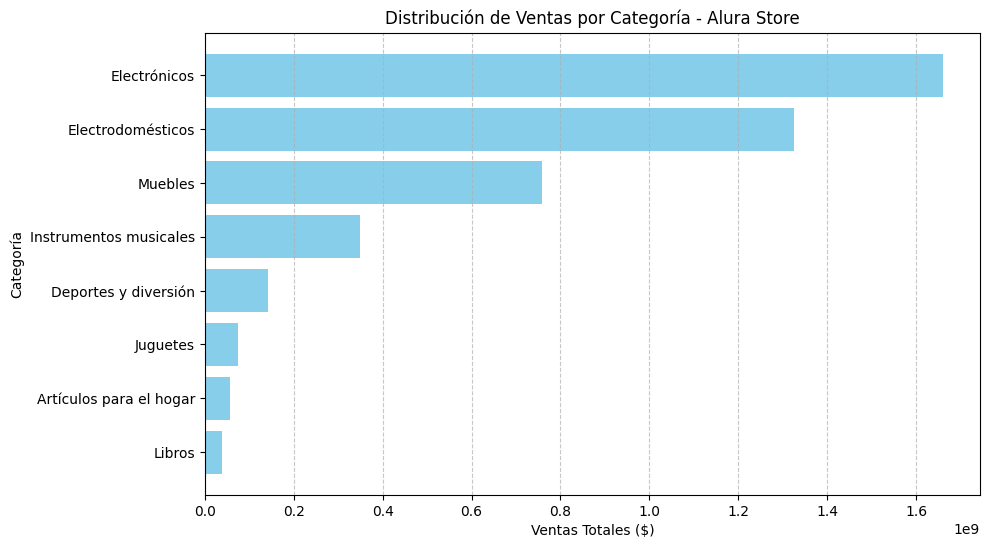

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(df_ventas_cat['Categoría'], df_ventas_cat['Total_Ventas'], color='skyblue')

plt.xlabel('Ventas Totales ($)')
plt.ylabel('Categoría')
plt.title('Distribución de Ventas por Categoría - Alura Store')
plt.gca().invert_yaxis()  # Para que la categoría con más ventas aparezca arriba
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 3. Calificación promedio de la tienda


In [11]:
# Calculamos el promedio de calificación por tienda
calificacion_tiendas = df_total.groupby('Tienda')['Calificación'].mean().reset_index()

# Ordenamos de mejor a peor para el análisis
calificacion_tiendas = calificacion_tiendas.sort_values(by='Calificación', ascending=False)

print("Calificación Promedio por Tienda:")
print(calificacion_tiendas)

Calificación Promedio por Tienda:
     Tienda  Calificación
2  Tienda 3      4.048326
1  Tienda 2      4.037304
3  Tienda 4      3.995759
0  Tienda 1      3.976685


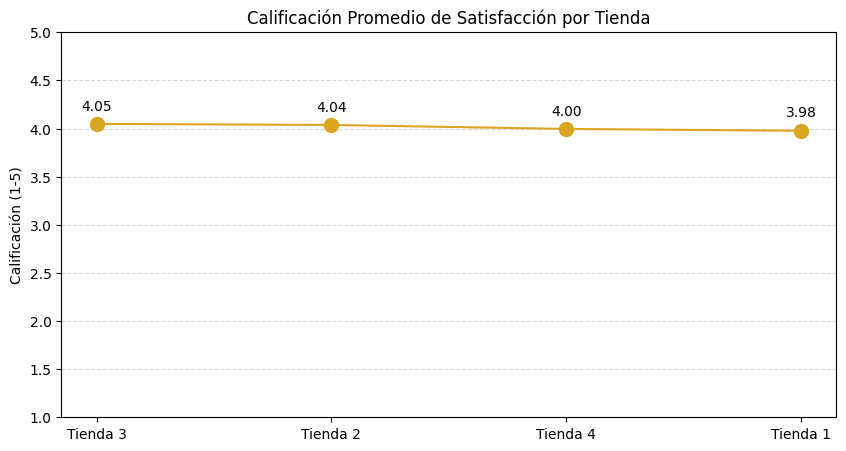

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(calificacion_tiendas['Tienda'], calificacion_tiendas['Calificación'], marker='o', linestyle='-', color='goldenrod', markersize=10)

# Añadimos etiquetas de datos para ser precisos
for i, txt in enumerate(calificacion_tiendas['Calificación']):
    plt.annotate(f'{txt:.2f}', (calificacion_tiendas['Tienda'].iloc[i], calificacion_tiendas['Calificación'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Calificación Promedio de Satisfacción por Tienda')
plt.ylabel('Calificación (1-5)')
plt.ylim(1, 5) # La escala siempre debe ser de 1 a 5
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 4. Productos más y menos vendidos

In [14]:
# Contamos cuántas veces aparece cada producto en el total de ventas
conteo_productos = df_total['Producto'].value_counts()

top_5_vendidos = conteo_productos.head(5)
bottom_5_vendidos = conteo_productos.tail(5)

print(" TOP 5 PRODUCTOS MÁS VENDIDOS ")
print(top_5_vendidos)
print("\n 5 PRODUCTOS MENOS VENDIDOS ")
print(bottom_5_vendidos)

 TOP 5 PRODUCTOS MÁS VENDIDOS 
Producto
Mesa de noche                210
Carrito de control remoto    206
Microondas                   206
Batería                      203
Cama king                    201
Name: count, dtype: int64

 5 PRODUCTOS MENOS VENDIDOS 
Producto
Ciencia de datos con Python    166
Guitarra eléctrica             165
Mochila                        163
Auriculares con micrófono      158
Celular ABXY                   157
Name: count, dtype: int64


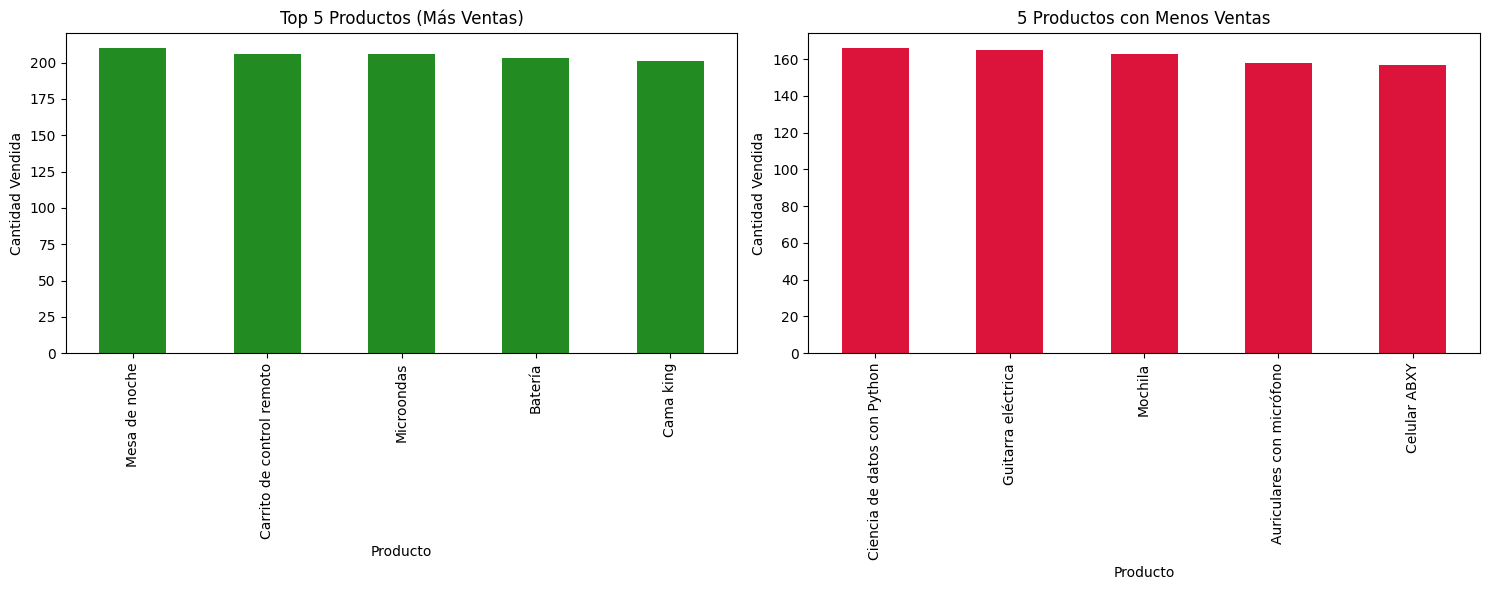

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de los más vendidos
top_5_vendidos.plot(kind='bar', ax=ax[0], color='forestgreen')
ax[0].set_title('Top 5 Productos (Más Ventas)')
ax[0].set_ylabel('Cantidad Vendida')

# Gráfico de los menos vendidos
bottom_5_vendidos.plot(kind='bar', ax=ax[1], color='crimson')
ax[1].set_title('5 Productos con Menos Ventas')
ax[1].set_ylabel('Cantidad Vendida')

plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [17]:
# Calculamos el promedio de envío por cada tienda
envio_tiendas = df_total.groupby('Tienda')['Costo de envío'].mean().reset_index()
envio_tiendas = envio_tiendas.sort_values(by='Costo de envío', ascending=False)

print("Costo de Envío Promedio por Tienda:")
print(envio_tiendas)

Costo de Envío Promedio por Tienda:
     Tienda  Costo de envío
0  Tienda 1    26018.609580
1  Tienda 2    25216.235693
2  Tienda 3    24805.680373
3  Tienda 4    23459.457167


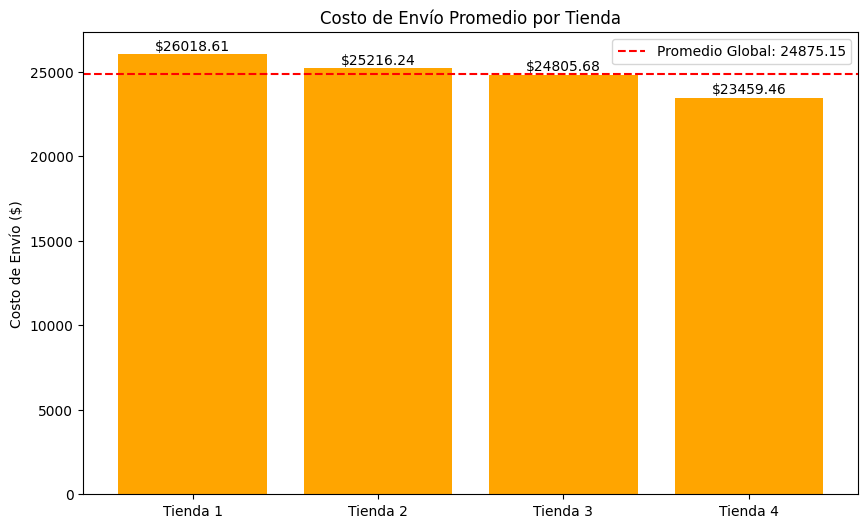

In [19]:
import matplotlib.pyplot as plt

promedio_global_envio = df_total['Costo de envío'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(envio_tiendas['Tienda'], envio_tiendas['Costo de envío'], color='orange')

# Añadir una línea de referencia del promedio global
plt.axhline(promedio_global_envio, color='red', linestyle='--', label=f'Promedio Global: {promedio_global_envio:.2f}')

plt.title('Costo de Envío Promedio por Tienda')
plt.ylabel('Costo de Envío ($)')
plt.legend()

# Etiquetas de valor sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f'${yval:.2f}', ha='center', va='bottom')

plt.show()